# House Price Regression & Heart Disease Classification

Supervised learning on two public datasets: regression on Ames Housing sale prices and binary classification on the Cleveland Heart Disease data. Each part covers exploration, a baseline model, a second model, feature selection, and an overfitting check.

## Part 1 — Regression: Ames Housing

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor

### Load and explore

In [147]:
# Load the CSV file into a DataFrame
df = pd.read_csv("ames_housing.csv")

# Display the first 5 rows
print (df.head())

# Print the shape of the dataset
print (df.shape)
# Print the column names and data types
print (df.dtypes)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

### Train/test split (numeric features, 80/20)

In [149]:
# Select only numeric columns from the DataFrame
df_numeric = df.select_dtypes(include=['number'])

# Drop columns that have missing values
colsIsNull = df_numeric.columns[df_numeric.isnull().sum() > 0]
df_numeric = df_numeric.drop(columns=colsIsNull)

# Drop any remaining rows with missing values
df_numeric = df_numeric.dropna()

# Separate into X (features) and y (target: SalePrice)
X = df_numeric.drop(columns=['SalePrice'])
y = df_numeric['SalePrice']

# Split into train and test sets (80/20), use random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1168
Test samples: 292
Number of features: 34


### Baseline: Linear Regression

In [150]:
# Create a LinearRegression model
model_baseline = LinearRegression()

# Fit the model on the training data
model_baseline.fit(X_train, y_train)

# Print the R² score on the test set
y_pred = model_baseline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R\u00b2 Score: {r2:.4f}")

R² Score: 0.8183


### Evaluation: R², MAE, RMSE

MAE: 22959.2109
R² Score: 0.8183
RMSE: 37327.5594


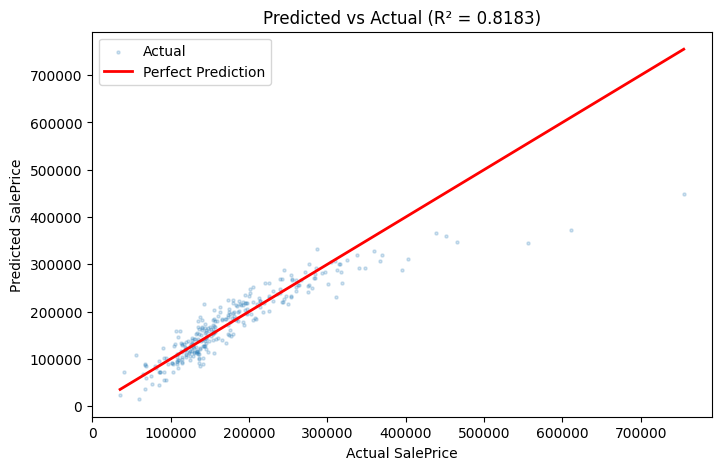

In [151]:
# Generate predictions on the test set
y_pred = model_baseline.predict(X_test)

# Compute and print R², MAE, and RMSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"R\u00b2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Create a predicted vs. actual scatter plot

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.2, s=5, label="Actual")

x_line = np.linspace(y_test.min(), y_test.max(), 100).reshape(-1, 1)
y_line = x_line
plt.plot(x_line, y_line, color="red", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Predicted vs Actual (R\u00b2 = {r2:.4f})")
plt.legend()
plt.show()

### Second model: Decision Tree Regressor

In [128]:
# Second regression model
model_second = DecisionTreeRegressor(random_state=42)

# Train it on the training data (same X_train as the baseline)
model_second.fit(X_train, y_train)

# Evaluate on the test set and print R², MAE
r2_second = model_second.score(X_test, y_test)
y_pred_second = model_second.predict(X_test)
mae_second = mean_absolute_error(y_test, y_pred_second)

print(f"Decision Tree R\u00b2: {r2_second:.4f}")
print(f"Decision Tree MAE: {mae_second:.4f}")
print("\n")

# Print a comparison of both models' scores
print(f"Linear Regression R\u00b2: {r2:.4f}")
print(f"Decision Tree R\u00b2: {r2_second:.4f}")

Decision Tree R²: 0.7022
Decision Tree MAE: 28304.0788


Linear Regression R²: 0.8183
Decision Tree R²: 0.7022


### Correlation with SalePrice

In [129]:
# Analyze which features are most correlated with SalePrice
corr_SalePrice = df_numeric.corr()["SalePrice"].sort_values(ascending=False)
print(corr_SalePrice)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
Fireplaces       0.466929
BsmtFinSF1       0.386420
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


### Feature selection

In [130]:
# Keep the features most correlated with SalePrice
selected_features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF", "FullBath", "YearBuilt", "YearRemodAdd"]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Retrain the Decision Tree on the selected features
model_selected =DecisionTreeRegressor(random_state=42)
model_selected.fit(X_train_selected, y_train)

# Evaluate and print R², MAE — compare to the model with all features
r2_select = model_selected.score(X_test_selected, y_test)
y_pred_select = model_selected.predict(X_test_selected)
mae_select = mean_absolute_error(y_test, y_pred_second)

print(f"Selected Features R\u00b2: {r2_select:.4f}")
print(f"Selected Features MAE: {mae_select:.4f}")
print("\n")

print(f"All Features R\u00b2: {r2_second:.4f}")
print(f"All Features MAE: {mae_second:.4f}")

Selected Features R²: 0.8198
Selected Features MAE: 28304.0788


All Features R²: 0.7022
All Features MAE: 28304.0788


### Overfitting check (train vs. test R²)

In [131]:
# Print the R² on TRAINING data and TEST data for both models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
}

print(f"{'Model':<25} {'Train R\u00b2':<10} {'Test R\u00b2':<10} {'Gap':<10}")
print("-" * 55)

for name, m in models.items():
    m.fit(X_train, y_train)
    train_score = m.score(X_train, y_train)
    test_score = m.score(X_test, y_test)
    gap = train_score - test_score
    print(f"{name:<25} {train_score:<10.4f} {test_score:<10.4f} {gap:<10.4f}")

Model                     Train R²   Test R²    Gap       
-------------------------------------------------------
Linear Regression         0.8036     0.8183     -0.0148   
Decision Tree             1.0000     0.7022     0.2978    


## Part 2 — Classification: Heart Disease

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

### Load and explore

In [133]:
# Load the CSV file into a DataFrame
df_heart = pd.read_csv("heart_disease.csv")

# Display the first 5 rows
print (df_heart.head())

# Print the shape of the dataset
print (df_heart.shape)

# Print the value counts of the target column to see class distribution
print(df_heart["condition"].value_counts())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
(297, 14)
condition
0    160
1    137
Name: count, dtype: int64


### Stratified train/test split (80/20)

In [134]:
# Separate into X (features) and y (target column)
X = df_heart.drop(columns=['condition'])
y = df_heart['condition']


# Split into train and test sets (80/20), use random_state=42, stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 237
Test samples:     60
Number of features: 13


### Baseline: Decision Tree Classifier

In [135]:
# Create the baseline classifier
clf_baseline = DecisionTreeClassifier(random_state=42)

# Fit the model on the training data
clf_baseline.fit(X_train, y_train)

# Print the accuracy on the test set
y_pred = clf_baseline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.7833


### Evaluation: accuracy, confusion matrix, classification report

Accuracy: 0.7833




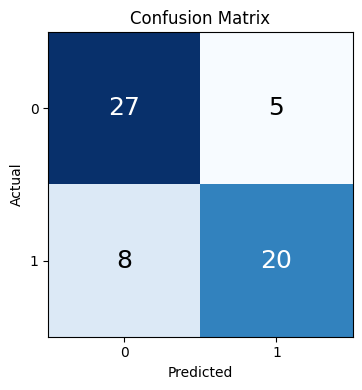



Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.81        32
           1       0.80      0.71      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



In [138]:
# Generate predictions on the test set
y_pred = clf_baseline.predict(X_test)

# Print the accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n")

# Display a confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=18,
                color="white" if cm[i, j] > cm.max()/2 else "black")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
#ax.set_xticklabels(data.target_names)
#ax.set_yticklabels(data.target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()
print("\n")

# Print the classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

### Correlation with the target

In [139]:
# Analyze feature importance or correlations
corr_condition = df_heart.corr()["condition"].sort_values(ascending=False)
print(corr_condition)

condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64


### Feature selection (with depth limits)

In [140]:
# Keep the features most correlated with the target
selected_features = ["thal", "ca", "oldpeak", "exang", "cp", "slope", "sex", "age", ]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Train a new classifier on the selected features
clf_selected = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf_selected.fit(X_train_selected, y_train)

# Evaluate and print accuracy — compare to baseline
y_pred_selected = clf_selected.predict(X_test_selected)
acc_selected = accuracy_score(y_test, y_pred_selected)

y_pred_baseline = clf_baseline.predict(X_test)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {acc_baseline:.4f}")
print(f"Selected Accuracy: {acc_selected:.4f}")

Baseline Accuracy: 0.7833
Selected Accuracy: 0.8500


### Second model: Random Forest

In [141]:
# Second classifier
clf_second = RandomForestClassifier(n_estimators=50, random_state=42)

# Train it on X_train_selected
clf_second.fit(X_train_selected, y_train)

# Evaluate on the test set — print accuracy and confusion matrix
y_predicted_second =  clf_second.predict(X_test_selected)
acc_second = accuracy_score(y_test, y_predicted_second)
print(f"Random Forest Accuracy: {acc_second:.4f}")
print("\n")

# Print a comparison of both models' accuracy scores
print(f"Decision Tree: {acc_selected:.4f}")
print(f"Random Forest: {acc_second:.4f}")

Random Forest Accuracy: 0.8333


Decision Tree: 0.8500
Random Forest: 0.8333


### Overfitting check (train vs. test accuracy)

In [142]:
# Print the accuracy on TRAINING data and TEST data for each model
print(f"Train Accuracy: {clf_baseline.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {clf_baseline.score(X_test, y_test):.4f}")
print("\n")

print(f"Train Accuracy: {clf_baseline.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {clf_baseline.score(X_test, y_test):.4f}")
print("\n")

print(f"Train Accuracy: {clf_second.score(X_train_selected, y_train):.4f}")
print(f"Test Accuracy:  {clf_second.score(X_test_selected, y_test):.4f}")

Train Accuracy: 1.0000
Test Accuracy:  0.7833


Train Accuracy: 1.0000
Test Accuracy:  0.7833


Train Accuracy: 0.9958
Test Accuracy:  0.8333


## Results

| Task | Model | Test score |
|---|---|---|
| Ames Housing (regression) | Linear Regression, all numeric features | R² 0.818 |
| Ames Housing (regression) | Decision Tree, all numeric features | R² 0.702 (train 1.000, overfits) |
| Ames Housing (regression) | Decision Tree, 8 selected features | R² 0.820 |
| Heart Disease (classification) | Decision Tree, all features | 78.3% accuracy (train 100%, overfits) |
| Heart Disease (classification) | Decision Tree, 8 selected features, max_depth=4 | 85.0% accuracy |
| Heart Disease (classification) | Random Forest, 8 selected features | 83.3% accuracy |